# Initialise tree community for LANDIS-II based on NBI

Last updated: 2026-08-12 <br>
Author: Stefan Vriend

In [1]:
conf_input_location <- "/home/jovyan/Cloud Storage/naa-vre-public/vl-veluwe-forest-model"
conf_tmp_data <- "/tmp/data"

In [3]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load("dplyr", "terra", "sf")

Loading required package: pacman

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘pacman’”
also installing the dependency ‘remotes’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [4]:
# Veluwe map retriever
#=========================================================
# Load and transform the Natura2000 Veluwe geopackage
natura2000_sf <- sf::read_sf("https://service.pdok.nl/rvo/natura2000/atom/downloads/natura2000.gpkg") |>
sf::st_transform(28992)

# Create the veluwe sf by filtering the Natura2000 shapefile 
veluwe_sf <- natura2000_sf |>
  dplyr::filter(objectid == 4049)

# Load LGN map
# LGN is Landelijk Grondgebruik Nederland, a national map about land use in the Netherlands.
# We use LGN5, which represents land use in 2003-2004 with a 25 meter resolution
# TODO: add option to select other versions of LGN
lgn5 <- terra::rast(file.path(conf_input_location, "LGN5.tif"))

# Turn sf object into vector
veluwe_vect <- terra::vect(veluwe_sf)

# Crop LGN map to Veluwe Natura2000
lgn5_veluwe <- terra::crop(lgn5, veluwe_vect) |>
    terra::mask(veluwe_vect)

# Retain cells that correspond to forest (11, broadleaf forest; 12, coniferous forest)
forest_codes <- c(11, 12)
veluwe_forest <- terra::ifel(lgn5_veluwe %in% forest_codes, 1, NA)

# Save the as geopackage to tmp data so that it can be used in later cells 
#veluwe_datafile <- file.path(conf_tmp_data, "veluwe.gpkg")
#sf::st_write(veluwe_forest, veluwe_datafile, append = FALSE)

In [21]:
# Initial communities data retriever & preprocessor 
#=========================================================
# Download the Microsoft Access database file that contains the most up-to-date data
# from MFV (NBI-5), NBI-6 and NBI-7 from the Probos website 
if (!file.exists(file.path(conf_tmp_data, "NBI.zip"))) {
    url <- "https://probos.nl/DB/NBI-7_openbare_database.zip"
    download.file(url, file.path(conf_tmp_data, "NBI.zip"), mode = "wb")
    unzip(file.path(conf_tmp_data, "NBI.zip"), exdir = conf_tmp_data)
}

# Remove space in unzipped file name
new_file <- file.path(conf_tmp_data, "NBI7_openbare_database_definitief_UpdateJuli2024.accdb")
if (!file.exists(new_file)) {
    file.rename(from = file.path(conf_tmp_data, "NBI7_openbare database_definitief_UpdateJuli2024.accdb"),
                to = new_file)
}
    
# Retrieve the relevant tables from the Microsoft Access database 
# - data_MFV_proefbomen contains measurements on individual sample trees, measurements of which are used to determine volume, biomass and growth of all other trees in a plot
# - data_MFV_boomgegevens contains measurements on individual trees within a plot, such as species and dbh, and estimations of volume, biomass and growth of trees
# - data_MFV_plotdefinitie contains a description of all MFV plots, such as plot id (plotnummer), location, surface area, municipality
# - data_MFV_plotmetingen contains measurements at the MFV plot level, such as sprouting year, soil type, ground water table
data_MFV_proefbomen <- Hmisc::mdb.get(new_file, tables = "data_MFV_proefbomen")
data_MFV_boomgegevens <- Hmisc::mdb.get(new_file, tables = "data_MFV_boomgegevens")
data_MFV_plotdefinitie <- Hmisc::mdb.get(new_file, tables = "data_MFV_plotdefinitie")
data_MFV_plotmetingen <- Hmisc::mdb.get(new_file, tables = "data_MFV_plotmetingen")

# Wrangle Access tables
# - convert diameter columns to cm
# - rename columns to English names and lowercase
# - retain only necessary columns
nbi5_forest_data <- data_MFV_boomgegevens |>
    tibble::as_tibble() |>
    dplyr::mutate(dbh_cm = .data$DIAMETER.MM / 10) |>
    dplyr::select("tree_number" = "BOOMNUMMER", "plot_number" = "PLOTNUMMER", "species_name" = "BOOMSOORT", "species_code" = "CODE.BOOMSOORT", 
                  "basal_area_m2" = "Grondvlak.m2", "dbh_cm", "volume_dm3" = "Volume.m3", "number_of_stems_ha" = "NstamHA", "biomass_stem_kg" = "Stambiomassa.kg", 
                  "biomass_branch_kg" = "Takbiomassa.kg", "biomass_leaf_kg" = "Bladbiomassa.kg", "biomass_root_kg" = "Wortelbiomassa.kg") |>
    type.convert(as.is = TRUE)

nbi5_plot_definition <- data_MFV_plotdefinitie |>
    dplyr::select("plot_number" = "PLOTNUMMER", "grid" = "GRID") |>
    type.convert(as.is = TRUE)

nbi5_plot_measurements <- data_MFV_plotmetingen |>
    dplyr::mutate("plot_size_ha" = .data$Plotoppervlak.totaal.dm2 / 1e06) |>
    dplyr::select("plot_number" = "PLOTNUMMER", "plot_size_ha", "top10_code" = "TOP10CODE", "measurement_date" = "OPNAMEDATUM", 
                  "germination_year" = "KIEMJAAR", "density_ha" = "Stamtal.ha.levend") |>
    type.convert(as.is = TRUE) |>
    dplyr::mutate("measurement_date" = as.Date(.data$measurement_date))

nbi5_sample_trees <- data_MFV_proefbomen |>
    dplyr::mutate("dbh_cm" = .data$DIAMETER.MM / 10) |>
    dplyr::select("plot_number" = "PLOTNUMMER", "species_name" = "BOOMSOORT", "species_code" = "CODE.BOOMSOORT", "height_m" = "HOOGTE.M") |>
    type.convert(as.is = TRUE)

## TODO
# 1a. Calculate ages
# 1b. What to do with 'rest' species?
# 2. Aggregate biomass by age class and scale to density

25 variables; Processing variable:1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 


In [22]:
# Filter NBI plots that are within the Veluwe
veluwe_plots <- nbi5_plot_definition |> 
    dplyr::mutate("lat" = as.integer(stringr::str_extract(.data$grid, "(?<=N)\\d+")) * 1000 + 500,
                  "lon" = as.integer(stringr::str_extract(.data$grid, "(?<=E)\\d+")) * 1000 + 500) |> 
    sf::st_as_sf(coords = c("lon", "lat"), 
                 crs = 3035) |> 
    sf::st_transform(crs = sf::st_crs(veluwe_forest)) |> 
    {\(.) dplyr::mutate(.,
                        "x" = sf::st_coordinates(.)[,1], 
                        "y" = sf::st_coordinates(.)[,2])}() |>
    terra::vect() |>
    terra::crop(veluwe_forest) |>
    terra::as.data.frame() |>
    dplyr::left_join(nbi5_plot_measurements, by = "plot_number")

# Associate age (based on germination year, kiemjaar) with sample trees
veluwe_sample_trees <- nbi5_sample_trees |> 
  dplyr::right_join(veluwe_plots |> 
                      dplyr::select("plot_number", "measurement_date", "germination_year"),
                    by = "plot_number") |> 
  dplyr::mutate("age" = lubridate::year(.data$measurement_date) - .data$germination_year)

In [242]:
# Create table with parameters for species-specific height growth models, from WUR-FEM reports
height_growth_parameters <- tibble::tribble(
    # ref_age = reference age; c1, c2, c3, c4 are model parameters
    ~"species", ~"ref_age", ~"c1", ~"c2", ~"c3", ~"c4",
    # Jansen et al. 2018a (https://edepot.wur.nl/444090), eq 10; c1, c2, c3 derived from Table 3, page 12
    "pinus sylvestris", 70L, 1.5162, 2500.5706, 22.0801, NA,
    # Jansen et al. 2018b (https://edepot.wur.nl/444089), eq 9; c1, c2, c3 derived from Table 3, page 14
    "picea abies", 50L, 1.7859, 2181.7777, 29.2173, NA,
    # Jansen et al. 2018c (https://edepot.wur.nl/444088), eq 12; c1, c2, c3 derived from Table 3 (North), page 15
    "larix kaempferi", 50L, 1.1565, 1259.1192, 34.2727, NA,
    # Jansen et al. 2018d (https://edepot.wur.nl/444093), eq 10; c1, c2, c3 derived from Table 3, page 11
    "quercus robur", 70L, 1.0690, 1449.4523, 34.2039, NA,
    # Jansen et al. 2018e (https://edepot.wur.nl/444094), eq 12; c1, c2, c3 derived from Table 3, page 14
    "fagus sylvatica", 70L, 1.2165, 5653.0980, 14.2701, NA,
    # Jansen et al. 2019f (https://edepot.wur.nl/444098), eq 7; c1, c2, c3 derived from Table 2, page 9
    "quercus rubra", NA, 0.0199, 5.2936, 0.1462, NA,
    # Jansen et al. 2016 (https://doi.org/10.3920/978-90-8686-827-8), eq 31; c1-c4 derived from Table 7, page 38
    "pseudotsuga menziesii", NA, 0.0278, 3.4405, 0.0557, 1.3872,
    # Jansen et al. 2018g (https://edepot.wur.nl/444102), eq 7; c1, c2, c3 derived from Table 3, page 10
    "betula pendula", 50L, 1.3198, 1065.6372, 16.4603, NA
)

# Create function to calculate height based on species, age (t) and the site index (boniteit)
calculate_height <- function(species, site_index, t) {

    # Get species-specific model parameters
    pars <- height_growth_parameters |> dplyr::filter(.data$species == {{species}})
    c1 <- pars$c1
    c2 <- pars$c2
    c3 <- pars$c3
    c4 <- pars$c4
    ref_age <- pars$ref_age

    if(species == "quercus rubra" ) {

        b <- c2 - c3 * site_index
        h_top <- site_index * (1 - exp(-c1 * t))^b

    } else if(species == "pseudotsuga menziesii") {

            b <- c2 - c3 * site_index
            t7 <- -log(1-(7/site_index)^(1/b)) / c1
            ak <- (c1 * b * (site_index / 7) * exp(-c1 * t7) * (1 - exp(-c1 * t7))^(b-1)) / (c4 * t7^(-c4 - 1))

            h_top <- dplyr::if_else(t <= t7, 
                                    7 * (exp(-ak * t^(-c4)))/(exp(-ak * t7^(-c4))),
                                    site_index * (1 - exp(-c1 * t))^b)
                               
    } else {

        Z <- site_index - c3
        R <- Z + sqrt(Z^2 + (2 * c2 * site_index) / (ref_age^c1))
        h_top <- site_index * ((t^c1) * ((ref_age^c1) * R + c2)) / ((ref_age^c1) * ((t^c1) * R + c2))
        
    }

    h_top
    
}

# Nonlinear least squares approach to finding the species-specific site indices for the Veluwe
find_site_index <- function(data, species, start, ...) {

    pars <- height_growth_parameters |> dplyr::filter(.data$species == {{species}})
    c1 <- pars$c1
    c2 <- pars$c2
    c3 <- pars$c3
    c4 <- pars$c4
    ref_age <- pars$ref_age

    # NB: For finding the site index, we use a simpler model for 'pseudotsuga menziesii' because the two-step model by Jansen et al. 2016 is too complicated to optimise
    # i.e., we use the logistic growth model for the full range of ages instead of only for the ages when height > 7 meters
    if(species %in% c("quercus rubra", "pseudotsuga menziesii")) {
        
        mod <- nls(height ~ site_index * (1 - exp(-c1 * t))^(c2 - c3 * site_index), 
                   data = data, start = start, ...)
        
    } else {

        mod <- nls(height ~ site_index * ((t^c1) * ((ref_age^c1) * ((site_index - c3) + sqrt((site_index - c3)^2 + (2 * c2 * site_index) / (ref_age^c1))) + c2)) / ((ref_age^c1) * ((t^c1) * ((site_index - c3) + sqrt((site_index - c3)^2 + (2 * c2 * site_index) / (ref_age^c1))) + c2)),
                   data = data, start = start, ...)
    }
    
    return(mod)
    
}

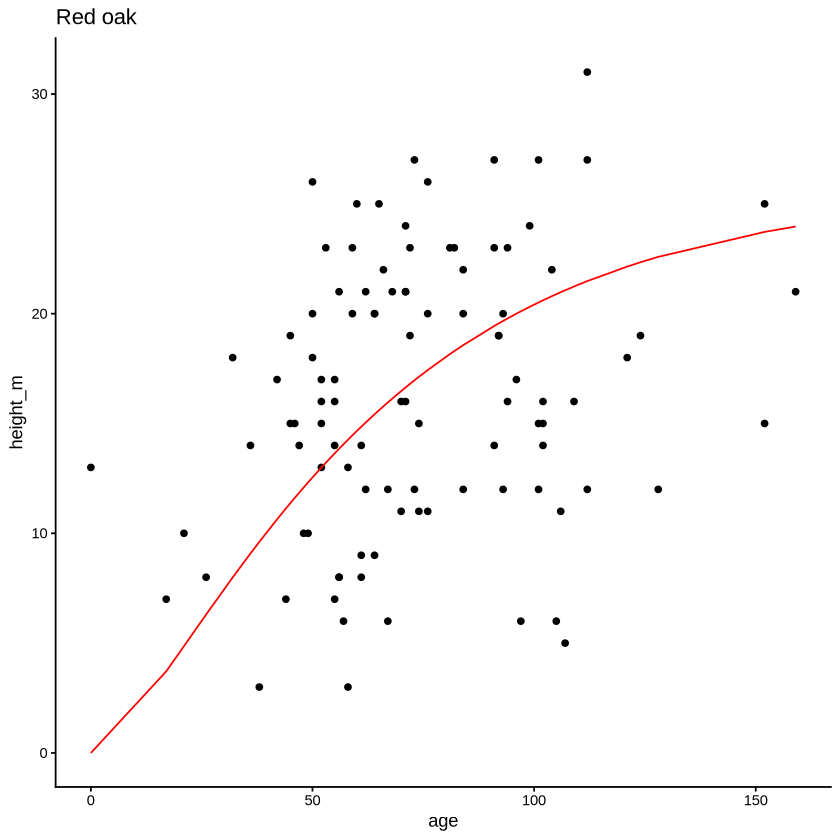

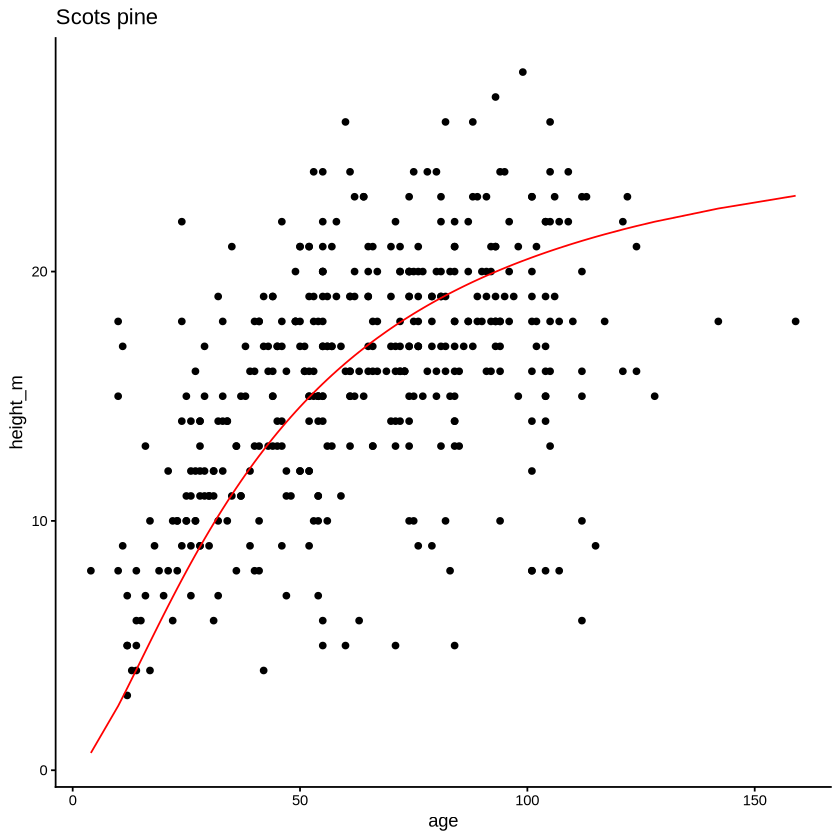

In [261]:
# Two examples, for Red Oak and Scots Pine
a <- find_site_index(data = veluwe_sample_trees |> dplyr::filter(.data$species_name == "Amerikaanse eik") |> dplyr::select("height" = "height_m", "t" = "age"),
                species = "quercus rubra", start = list(site_index = 25))

b <- find_site_index(data = veluwe_sample_trees |> dplyr::filter(.data$species_name == "Grove den") |> dplyr::select("height" = "height_m", "t" = "age"),
                species = "pinus sylvestris", start = list(site_index = 25))

veluwe_sample_trees |> 
  dplyr::filter(.data$species_name == "Amerikaanse eik") |>
  dplyr::mutate(htop = calculate_height("quercus rubra", site_index = coefficients(a), age)) |> 
  ggplot2::ggplot() +
  ggplot2::geom_point(mapping = ggplot2::aes(x = age, y = height_m)) +
  ggplot2::geom_line(mapping = ggplot2::aes(x = age, y = htop), color = "red") +
  ggplot2::labs(title = "Red oak") + 
  ggplot2::theme_classic()

veluwe_sample_trees |> 
  dplyr::filter(.data$species_name == "Grove den") |>
  dplyr::mutate(htop = calculate_height("pinus sylvestris", site_index = coefficients(b), age)) |> 
  ggplot2::ggplot() +
  ggplot2::geom_point(mapping = ggplot2::aes(x = age, y = height_m)) +
  ggplot2::geom_line(mapping = ggplot2::aes(x = age, y = htop), color = "red") +
  ggplot2::labs(title = "Scots pine") + 
  ggplot2::theme_classic()